## <center> Функция read_table()

In [1]:
# Импорт библиотеки pandas — при выполнении последовательно всех примеров ниже
# импорт выполняется один раз
import pandas as pd 
# Загружаем данные из файла в переменную, создавая объект DataFrame
countries_data = pd.read_csv('data/countries.csv', sep=';') 
# Выгружаем данные из DataFrame в CSV-файл и сохраняем файл в папке data
countries_data.to_csv('data/countries.txt', index=False, sep=' ')

Считаем данные из файла ```countries.txt``` в переменную ```txt_df```  (объект DataFrame), применив функцию ```read_table()``` с параметрами ```sep=' '```  и  ```index_col=['country']``` (так мы избавимся от столбца с индексом и присвоим названия строкам, используя данные одного из столбцов). Выводим на экран полученный результат:

In [2]:
# Загружаем данные из файла в переменную, создавая объект DataFrame
txt_df = pd.read_table('data/countries.txt', sep=' ', index_col=['country'])
# Выводим содержимое DataFrame на экран
display(txt_df)

,population,square
country,,
Англия,56.29,133396
Канада,38.05,9984670
США,322.28,9826630
Россия,146.24,17125191
Украина,45.50,603628
Беларусь,9.50,207600
Казахстан,17.04,2724902


### <center> Применение параметра header

Используя параметр ```header```, при создании DataFrame мы учитываем наличие/отсутствие строки заголовков в исходном файле данных.

Например, если при считывании данных из ранее сохранённого в папке data файла melb_data_ps.csv указать значение параметра ```header=None```, то первая строка исходного файла не будет восприниматься как строка заголовка и будет отнесена к области данных DataFrame:

```python
# Загружаем данные из файла в переменную, создавая объект DataFrame
melb_data = pd.read_csv('data/melb_data_ps.csv', header=None) 
# Выводим содержимое DataFrame на экран
display(melb_data)
```

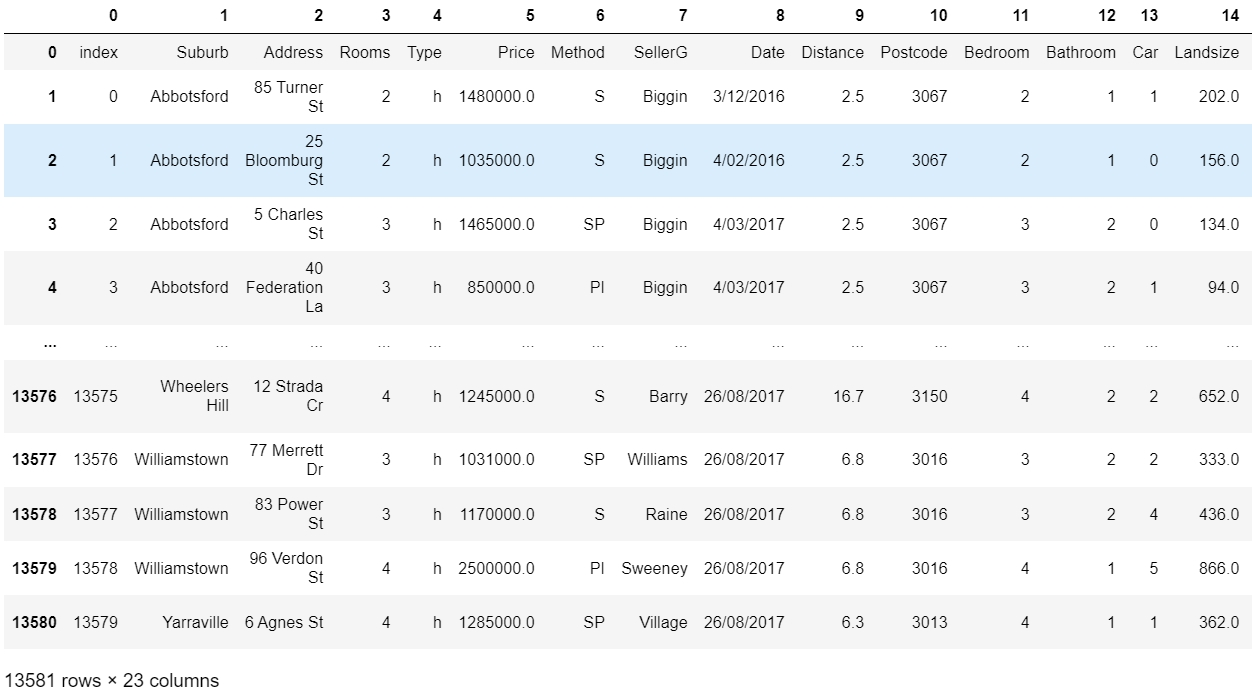

### Решаем проблему с кодировкой исходных данных

При считывании файла и создании DataFrame может возникнуть проблема — при выводе на экран данные будут отображаться в виде нечитаемых символов. Это связано с кодировкой символов в исходном файле.

Для решения проблемы выполним следующие действия:
* узнаем, какая кодировка символов используется в считываемом файле, для этого обратимся к субмодулю chardet.universaldetector библиотеки Universal Encoding Detector. Модуль необходимо предварительно установить с помощью стандартной команды менеджера пакетов pip: pip install chardet;
* при считывании файла и создании DataFrame будем использовать параметр encoding  —  указывает, какой тип кодировки символов используется в считываемом файле.

Считываем файл и создаем DataFrame без использования параметра encoding:

In [3]:
import pandas as pd

In [4]:
# Считываем данные из файла с неизвестной кодировкой в переменную, создавая объект DataFrame
data=pd.read_csv('data/ErrorEnCoding.csv', header=None, encoding_errors='replace') 
# Выводим содержимое DataFrame на экран
display(data)

,0,1,2
0,User_943,Accumanst@gmail.com,������
1,User_908,Advismowr@mail.ru,������
2,User_962,Anachso@ukr.net,���������
3,User_973,Antecia@inbox.ru,�����
4,User_902,Balliaryva@ukr.net,
...,...,...,...
95,User_959,UpdatesCurious@yahoo.com,������
96,User_901,V2artierso@mail.ru,�����������
97,User_970,Vashoterlo@bk.ru,�������
98,User_965,Visuareda@yahoo.com,�������


Выявлена проблема: при стандартном считывании содержимое файла читается некорректно. Необходимо указать кодировку файла при считывании.

### Определяем кодировку файла

In [ ]:
# Импортируем субмодуль chardet.universal

from chardet import UniversalDetector

detector = UniversalDetector()

with open('data/ErrorEnCoding.csv', 'rb') as fh:
    for line in fh:
        detector.feed(line)
        if detector.done:
            break
print(detector.close())

{'encoding': 'koi8-r', 'confidence': 0.31946375814590433, 'language': 'ru'}


### Считываем файл, указав кодировку

In [8]:
# Создаем DataFrame из файла, явно указав кодировку символов, и выводим его содержимое на экран
data=pd.read_csv('data/ErrorEnCoding.csv', encoding='koi8-r', header=None)
display(data)

,0,1,2
0,User_943,Accumanst@gmail.com,Ижевск
1,User_908,Advismowr@mail.ru,Ижевск
2,User_962,Anachso@ukr.net,Краснодар
3,User_973,Antecia@inbox.ru,Пермь
4,User_902,Balliaryva@ukr.net,
...,...,...,...
95,User_959,UpdatesCurious@yahoo.com,Тюмень
96,User_901,V2artierso@mail.ru,Арзангелтск
97,User_970,Vashoterlo@bk.ru,Воронеж
98,User_965,Visuareda@yahoo.com,Воронеж


## Чтение файла по ссылке, используя функцию read_table()

In [10]:
data = pd.read_table('https://raw.githubusercontent.com/esabunor/MLWorkspace/master/melb_data.csv', sep=',')
display(data)
data.shape[0]

,Unnamed: 0,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.79960,144.99840,Northern Metropolitan,4019.0
1,2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.80790,144.99340,Northern Metropolitan,4019.0
2,4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.80930,144.99440,Northern Metropolitan,4019.0
3,5,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.79690,144.99690,Northern Metropolitan,4019.0
4,6,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.80720,144.99410,Northern Metropolitan,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18391,23540,Williamstown,8/2 Thompson St,2,t,622500.0,SP,Greg,26/08/2017,6.8,...,2.0,1.0,NaN,89.0,2010.0,NaN,-37.86393,144.90484,Western Metropolitan,6380.0
18392,23541,Williamstown,96 Verdon St,4,h,2500000.0,PI,Sweeney,26/08/2017,6.8,...,1.0,5.0,866.0,157.0,1920.0,NaN,-37.85908,144.89299,Western Metropolitan,6380.0
18393,23544,Yallambie,17 Amaroo Wy,4,h,1100000.0,S,Buckingham,26/08/2017,12.7,...,3.0,2.0,NaN,NaN,NaN,NaN,-37.72006,145.10547,Northern Metropolitan,1369.0
18394,23545,Yarraville,6 Agnes St,4,h,1285000.0,SP,Village,26/08/2017,6.3,...,1.0,1.0,362.0,112.0,1920.0,NaN,-37.81188,144.88449,Western Metropolitan,6543.0


18396

### Чтение/запись архивированных CSV-файлов

In [13]:
data = pd.read_csv('data/students_performance.zip')
display(data)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


В функции to_csv() предусмотрен механизм, позволяющий проводить упаковку CSV-файлов в zip-архив. Проделаем обратную операцию — данные из DataFrame data запишем в CSV-файл, упакуем полученный файл в zip-архив «на лету» и сохраним полученный архив в папке data, выполнив следующий код:

In [14]:
# Определяем параметры архивирования — метод сжатия, имя файла в архиве
compression_opts = dict(method='zip', archive_name='out.csv') 
data.to_csv('data/out.zip', index=False, compression=compression_opts)

------------

## <center> Считывание данных из файла Excel

In [15]:
grades = pd.read_excel('data/grades.xlsx')
display(grades.head())

,Student ID,Student name,Grade
0,1,Аня,8
1,2,Катя,9
2,3,Маша,7
3,4,Миша,4
4,5,Женя,8


### Считывание данных из файла EXCEL по ссылке

In [16]:
data = pd.read_excel('https://github.com/asaydn/test/raw/master/january.xlsx', skiprows=3)
display(data)

,Location,Oranges,Apples,Bananas,Blueberries,Total
0,Toronto,7651,4422,8580,3679,24332
1,Los Angeles,273,2998,9890,7293,20454
2,Atlanta,3758,6752,4599,4149,19258
3,New York,4019,8796,8486,9188,30489


[Документация по EXCEL](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_excel.html)

***Основные параметры метода read_excel()***:
* io — первый параметр, в который мы передаём адрес файла, который хотим прочитать. Кроме адреса на диске, можно передавать адрес в интернете.
* sheet_name —  ссылка на лист в Excel-файле (возможные значения данного параметра: 0 — значение по умолчанию, загружается первый лист; 'Sheet1' — можно передать название листа; обычно листы называются 'SheetX', где X — номер листа, но могут использоваться и другие названия; [0, 1, 'Sheet3'] — список, содержащий номера или названия листов; в таком случае Pandas вернёт словарь, в котором ключами будут номера или названия листов, а значениями — их содержимое в виде DataFrame; None — если передать такое значение, то pandas прочитает все листы и вернёт их в виде словаря, как в предыдущем пункте).
* na_values — список значений, которые будут считаться пропусками ( ‘’, ‘#N/A’, ‘ N/A’, ‘#NA’, ‘-1.#IND’, ‘-1.#QNAN’, ‘-NaN’, ‘-nan’, ‘1.#IND’, ‘1.#QNAN’, ‘NA’, ‘NULL’, ‘NaN’, ‘n/a’, ‘nan’, ‘null’).

Следует также учесть, что нормальное поведение pandas — это считывание значений (формулы из Excel-файла не считываются).

Как упоминалось выше, один Excel-файл может включать в себя несколько листов, которые отображаются в разных вкладках (англ. sheet, рус. лист). Например, в нашем файле два листа — Maths и ML.

По умолчанию в DataFrame читается информация из первого листа, однако read_excel()  позволяет выбрать, из какого именно листа загружать данные. Сделать это можно с помощью параметра sheet_name (рус. имя_листа). Например, чтобы прочесть данные из второго листа (ML) файла, выполним код:

In [18]:
grades = pd.read_excel('data/grades.xlsx', sheet_name='ML')
display(grades.head())

,Student ID,Student name,Grade
0,1,Аня,7
1,2,Катя,5
2,3,Маша,9
3,4,Миша,8
4,5,Женя,9


In [29]:
mask = grades['Student name'] == 'Катя'
r = grades[mask].index[0]
print(f'за экзамен по машинному обучению (ML) Катя получила {grades['Grade'][r]}')

за экзамен по машинному обучению (ML) Катя получила 5


In [30]:
grades = pd.read_excel('data/grades.xlsx', sheet_name='Maths')
display(grades.head())

,Student ID,Student name,Grade
0,1,Аня,8
1,2,Катя,9
2,3,Маша,7
3,4,Миша,4
4,5,Женя,8


Какую отметку за экзамен по математике (Maths) получил Миша?

In [32]:
mask = grades['Student name'] == 'Миша'
r = grades[mask].index[0]
print(f'за экзамен по машинному обучению (Maths) Миша получил {grades['Grade'][r]}')

за экзамен по машинному обучению (Maths) Миша получил 4


### Выгрузка данных из DataFrame в Excel-файл

После обработки данных (очистка, создание новых признаков и т. д.) методами и функциями pandas мы сталкиваемся с обратной задачей — сохранить данные из DataFrame в Excel-файл.

Для этого в pandas есть функция to_excel() (рус. в_Excel), принцип работы которой очень схож с функцией to_csv():

In [33]:
# Сохраняем данные из DataFrame grades в файл grades_new.xlsx в папке data
grades.to_excel('data/grades_new.xlsx')

В этом случае будет создан один лист с именем по умолчанию "Sheet1". Также мы сохраним и индекс — в данных будет находиться лишний столбец. Чтобы создать лист с определённым именем (например, Example) и не сохранять индекс, в метод  to_excel() необходимо передать параметры sheet_name='Example' и index=False:

In [35]:
# Сохраняем данные из DataFrame grades в файл grades_new.xlsx (на листе 'Example') в папке data
grades.to_excel('data/grades_new.xlsx', sheet_name='Example', index=False)

[Документация to_excel](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.to_excel.html)

Продвинутая работа с файлами Excel в Python предполагает использование дополнительных библиотек, таких как:
* [openpyxl](https://openpyxl.readthedocs.io/en/stable/) — рекомендуемый пакет для чтения и записи файлов Excel 2010+ (например, xlsx);
* [xlsxwriter](https://xlsxwriter.readthedocs.io/) — альтернативный пакет для записи данных, информации о форматировании и, в частности, диаграмм в формате Excel 2010+ (например, xlsx);
* [pyxlsb](https://pypi.org/project/pyxlsb/) — пакет позволяет читать файлы Excel в xlsb-формате;
* [pylightxl](https://pylightxl.readthedocs.io/en/latest/) — пакет позволяет читать xlsx- и xlsm-файлы и записывать xlsx-файлы;
* [xlrd](https://xlrd.readthedocs.io/en/latest/) — пакет предназначен для чтения данных и информации о форматировании из старых файлов Excel (например, xls);
* [xlwt](https://xlwt.readthedocs.io/en/latest/) — пакет предназначен для записи данных и информации о форматировании в старые файлы Excel (например, xls).

In [39]:
ratings = pd.read_excel('data/ratings_movies.xlsx', sheet_name='ratings')
display(ratings.head())

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [38]:
movies = pd.read_excel('data/ratings_movies.xlsx', sheet_name='movies')
display(movies.head())

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [44]:
merged = ratings.merge(movies, how='left', on='movieId')
display(merged.head())
merged.shape

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


(100836, 6)